# Anvitha Voice Emotion Model

Train an LSTM on TESS speech data (MFCC features) for emotion recognition. Clean design with config, helpers, and full save to `model_output_dir`.

In [1]:
import pandas as pd
import numpy as np
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

# Optional: Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False


Mounted at /content/drive


## 1. Configuration

Central place for paths. Use Colab paths when in Colab, else local.

In [2]:
# Plot style for better-looking figures
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 100
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

if IN_COLAB:
    DATASET_ROOT = '/content/drive/MyDrive/datasets/anvitha/'
    MODEL_OUTPUT_DIR = '/content/drive/MyDrive/models/anvitha'
    TESS_DIR = os.path.join(DATASET_ROOT, 'tess_dataset')
else:
    BASE = os.getcwd()
    MODEL_OUTPUT_DIR = os.path.join(BASE, 'models', 'anvitha')
    TESS_DIR = os.path.join(BASE, 'tess_dataset')
    if not os.path.isdir(TESS_DIR):
        TESS_DIR = os.path.join(BASE, 'TESS Toronto emotional speech set data')
    DATASET_ROOT = os.path.dirname(TESS_DIR)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
print(f'Dataset root: {DATASET_ROOT}')
print(f'Model output dir: {MODEL_OUTPUT_DIR}')


Dataset root: /content/drive/MyDrive/datasets/anvitha/
Model output dir: /content/drive/MyDrive/models/anvitha


## 2. Load Dataset

Scan TESS directory and build paths + labels from filenames.

In [3]:
def load_tess_paths_and_labels(tess_dir, max_files=2800):
    paths, labels = [], []
    for dirname, _, filenames in os.walk(tess_dir):
        for filename in filenames:
            if not filename.lower().endswith('.wav'):
                continue
            paths.append(os.path.join(dirname, filename))
            label = filename.split('_')[-1].split('.')[0].lower()
            labels.append(label)
        if len(paths) >= max_files:
            break
    return paths[:max_files], labels[:max_files]

paths, labels = load_tess_paths_and_labels(TESS_DIR)
df = pd.DataFrame({'speech': paths, 'label': labels})
print(f'Loaded {len(df)} samples.')
df.head()


Loaded 2800 samples.


,speech,label
0,/content/drive/MyDrive/datasets/anvitha/tess_d...,disgust
1,/content/drive/MyDrive/datasets/anvitha/tess_d...,angry
2,/content/drive/MyDrive/datasets/anvitha/tess_d...,angry
3,/content/drive/MyDrive/datasets/anvitha/tess_d...,disgust
4,/content/drive/MyDrive/datasets/anvitha/tess_d...,angry


## 3. Exploratory Data Analysis

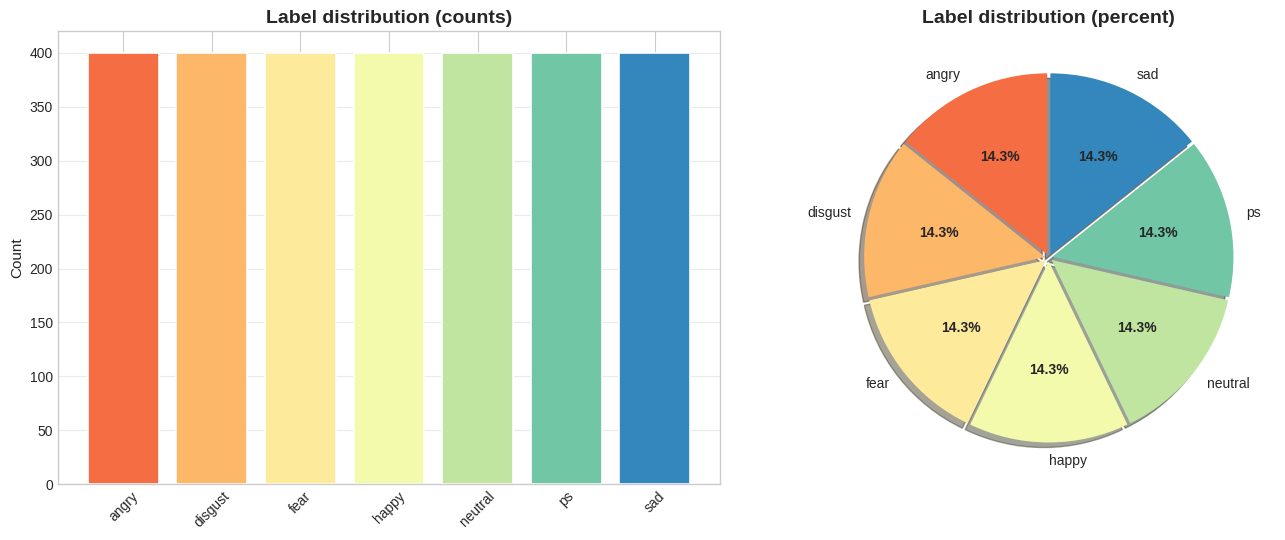

In [4]:
counts = df['label'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.Spectral(np.linspace(0.2, 0.9, len(counts)))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Label distribution (counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_axisbelow(True)
wedges, texts, autotexts = axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=[0.02]*len(counts), shadow=True)
for t in autotexts:
    t.set_fontweight('bold')
axes[1].set_title('Label distribution (percent)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Audio visualization helpers

Waveform and spectrogram for a single audio path.

In [5]:
def waveplot(data, sr, emotion, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_title(emotion.title(), size=14, fontweight='bold')
    librosa.display.waveshow(data, sr=sr, ax=ax, color='#2E86AB')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.4)

def spectrogram(data, sr, emotion, ax=None):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(np.abs(X))
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 3.2))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz', ax=ax, cmap='magma')
    ax.set_title(emotion.title(), size=14, fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')
    return img

def plot_sample_for_emotion(emotion, df, sample_idx=0):
    subset = df[df['label'] == emotion]
    if subset.empty:
        print(f'No samples for {emotion}')
        return
    path = subset['speech'].iloc[sample_idx]
    data, sr = librosa.load(path)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))
    fig.suptitle(f'Sample: {emotion.title()}', fontsize=14, fontweight='bold', y=1.02)
    waveplot(data, sr, emotion, ax=axes[0])
    img = spectrogram(data, sr, emotion, ax=axes[1])
    plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    return path


### Sample waveform & spectrogram per emotion

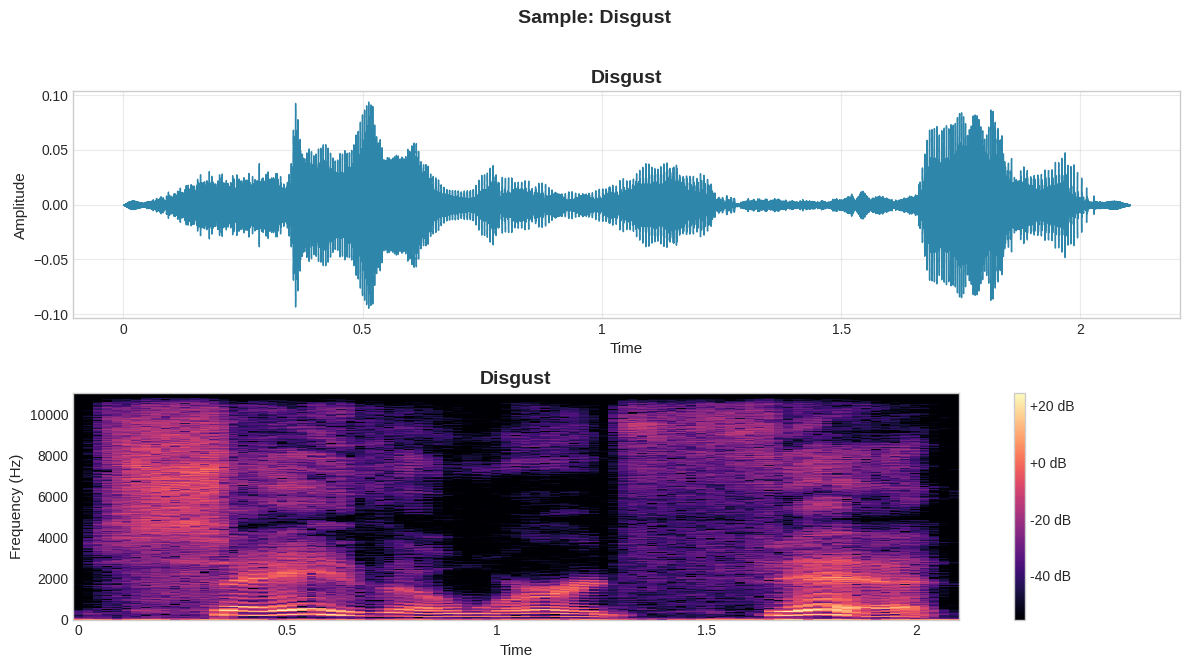

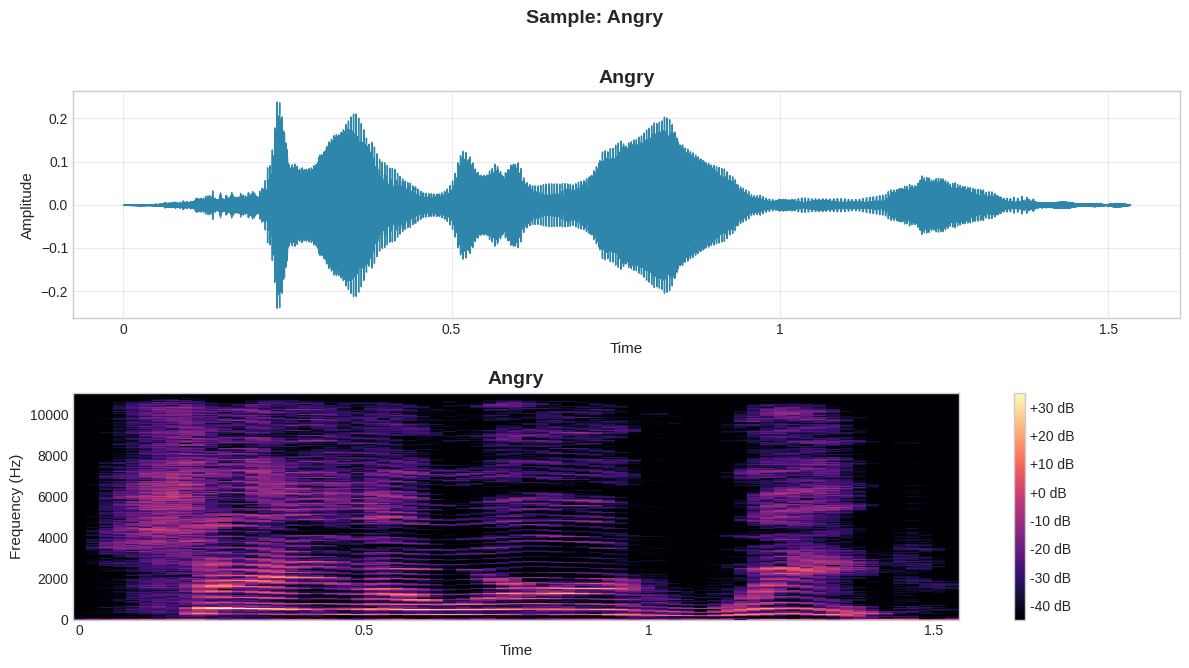

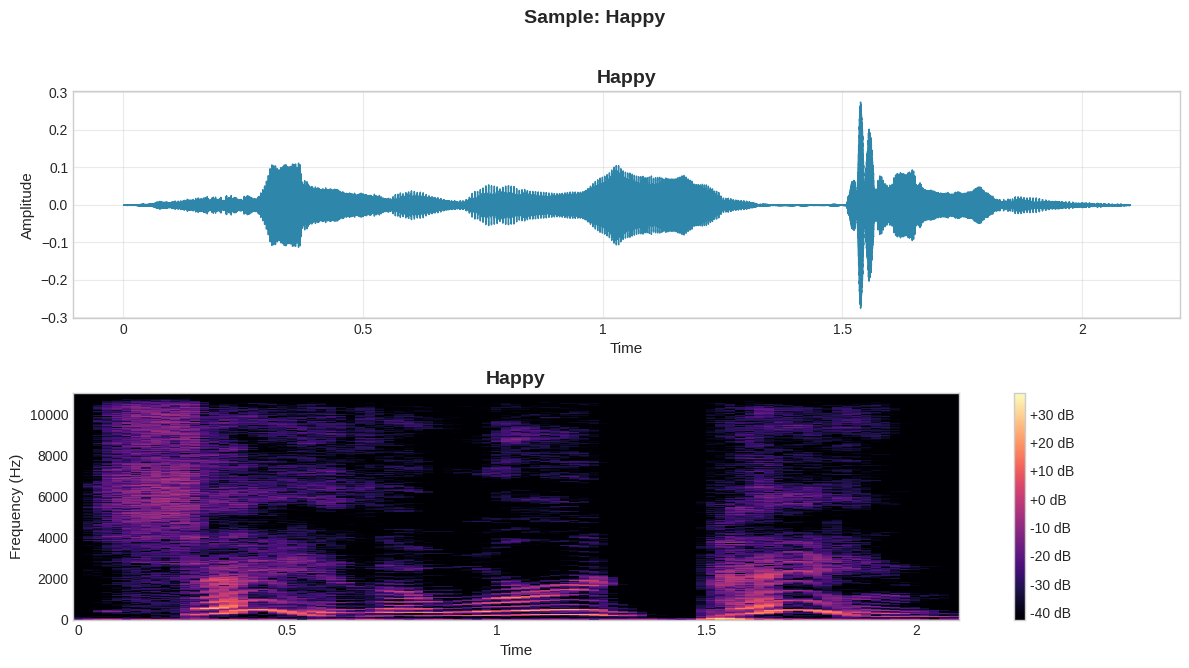

In [6]:
emotions = df['label'].unique().tolist()
for em in emotions[:3]:  # show first 3 to keep notebook fast
    plot_sample_for_emotion(em, df, sample_idx=0)


## 5. Feature extraction (MFCC)

Extract 40 MFCC coefficients per clip (3s, offset 0.5s).

In [7]:
def extract_mfcc(filename, n_mfcc=40, duration=3, offset=0.5):
    y, sr = librosa.load(filename, duration=duration, offset=offset)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T, axis=0)
    return mfcc

X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))
X = np.array([x for x in X_mfcc])
X = np.expand_dims(X, -1)
print(f'X shape: {X.shape}')


X shape: (2800, 40, 1)


### MFCC heatmap (sample per emotion)

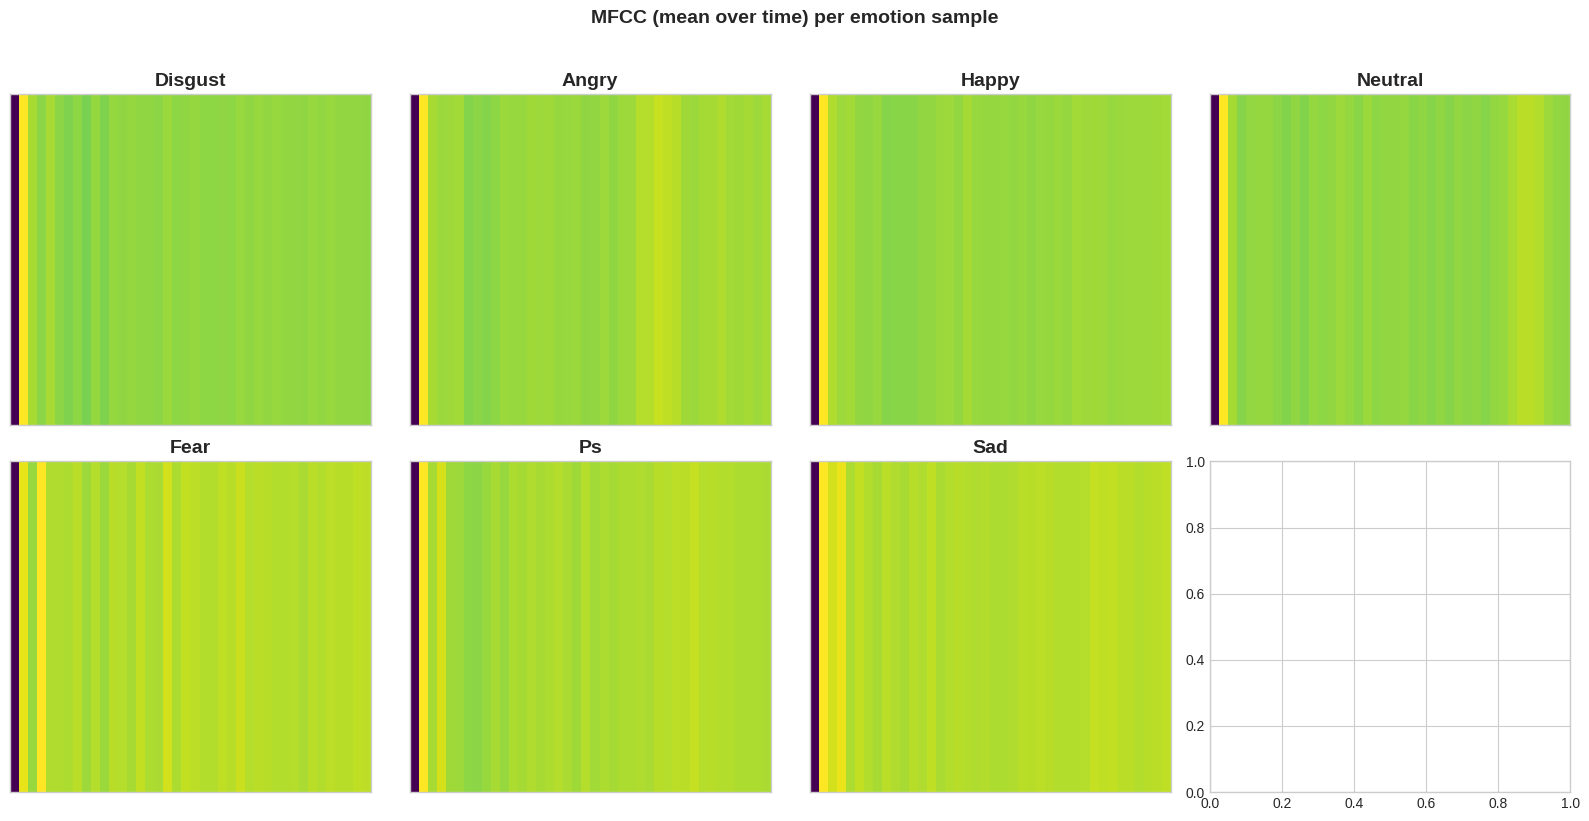

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, em in enumerate(emotions):
    if i >= len(axes):
        break
    idx = df[df['label'] == em].index[0]
    mfcc_row = X_mfcc.iloc[idx]
    mfcc_2d = mfcc_row.reshape(1, -1)
    im = axes[i].imshow(mfcc_2d, aspect='auto', cmap='viridis', vmin=mfcc_2d.min(), vmax=mfcc_2d.max())
    axes[i].set_title(em.title(), fontweight='bold')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.suptitle('MFCC (mean over time) per emotion sample', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Mean MFCC profile by emotion (first 20 coefficients)

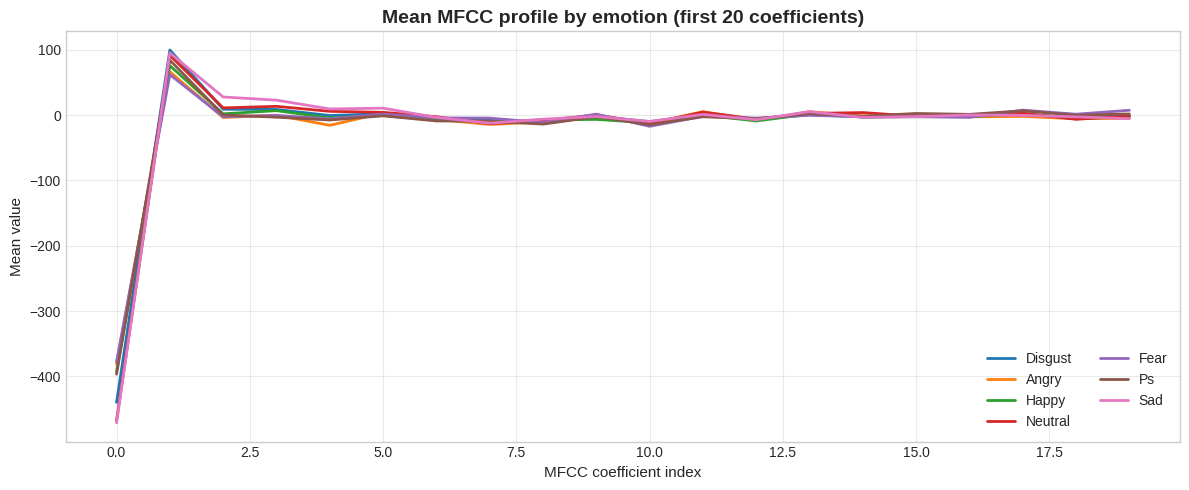

In [9]:
# Mean MFCC per emotion (average across all samples of that emotion)
mfcc_by_emotion = df.groupby('label').apply(lambda g: np.array(X_mfcc.iloc[g.index].tolist()).mean(axis=0))
n_coefs = 20
fig, ax = plt.subplots(figsize=(12, 5))
for em in emotions:
    ax.plot(range(n_coefs), mfcc_by_emotion.loc[em][:n_coefs], label=em.title(), linewidth=2)
ax.set_xlabel('MFCC coefficient index')
ax.set_ylabel('Mean value')
ax.set_title('Mean MFCC profile by emotion (first 20 coefficients)', fontsize=14, fontweight='bold')
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Encode labels

In [10]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']]).toarray()
print(f'y shape: {y.shape}')


y shape: (2800, 7)


## 7. Train / validation split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}')


Train: 2240, Val: 560


## 8. Model (LSTM)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40, 1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Training

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64
)


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3826 - loss: 1.5525 - val_accuracy: 0.7929 - val_loss: 0.5302
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7939 - loss: 0.5262 - val_accuracy: 0.9089 - val_loss: 0.2727
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8995 - loss: 0.2952 - val_accuracy: 0.9304 - val_loss: 0.1931
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9325 - loss: 0.2099 - val_accuracy: 0.9089 - val_loss: 0.3411
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9310 - loss: 0.2284 - val_accuracy: 0.9696 - val_loss: 0.1026
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9710 - loss: 0.1090 - val_accuracy: 0.9696 - val_loss: 0.1024
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9663 - loss: 0.1263 - val_accuracy: 0.9679 - val_loss: 0.0905
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9681 - loss: 0.1017 - val_accuracy: 0.9589 - val

## 10. Training curves

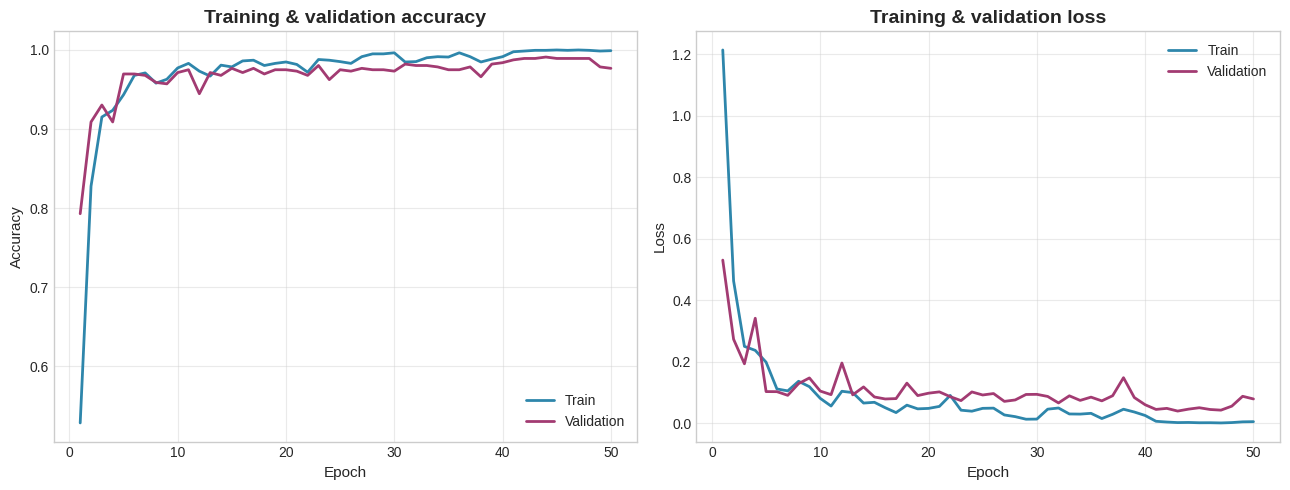

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)
axes[0].plot(epochs_range, history.history['accuracy'], label='Train', color='#2E86AB', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Validation', color='#A23B72', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & validation accuracy', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.4)
axes[0].set_axisbelow(True)
axes[1].plot(epochs_range, history.history['loss'], label='Train', color='#2E86AB', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Validation', color='#A23B72', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & validation loss', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)
axes[1].set_axisbelow(True)
plt.tight_layout()
plt.show()


## 10b. Evaluation metrics (table)

Accuracy, precision, recall, and F1 score on the validation set.

In [15]:
# Metrics table (run after training)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

y_val_pred = model.predict(X_val, verbose=0)
y_val_pred_idx = np.argmax(y_val_pred, axis=1)
y_val_idx = np.argmax(y_val, axis=1)
class_names = list(enc.categories_[0])

# Overall metrics summary table
metrics_data = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Precision (weighted)',
               'Recall (macro)', 'Recall (weighted)',
               'F1 (macro)', 'F1 (weighted)'],
    'Score': [
        accuracy_score(y_val_idx, y_val_pred_idx),
        precision_score(y_val_idx, y_val_pred_idx, average='macro', zero_division=0),
        precision_score(y_val_idx, y_val_pred_idx, average='weighted', zero_division=0),
        recall_score(y_val_idx, y_val_pred_idx, average='macro', zero_division=0),
        recall_score(y_val_idx, y_val_pred_idx, average='weighted', zero_division=0),
        f1_score(y_val_idx, y_val_pred_idx, average='macro', zero_division=0),
        f1_score(y_val_idx, y_val_pred_idx, average='weighted', zero_division=0),
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df['Score'] = metrics_df['Score'].round(4)
print('Validation-set metrics')
display(metrics_df)

# Per-class metrics table
report = classification_report(
    y_val_idx, y_val_pred_idx, target_names=class_names,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
per_class = report_df.loc[class_names]
print('\nPer-class metrics (precision, recall, f1-score)')
display(per_class)

Validation-set metrics


,Metric,Score
0,Accuracy,0.9768
1,Precision (macro),0.9773
2,Precision (weighted),0.9773
3,Recall (macro),0.9768
4,Recall (weighted),0.9768
5,F1 (macro),0.9769
6,F1 (weighted),0.9769



Per-class metrics (precision, recall, f1-score)


,precision,recall,f1-score,support
angry,0.9875,0.9875,0.9875,80.0
disgust,0.9737,0.9250,0.9487,80.0
fear,1.0000,0.9875,0.9937,80.0
happy,0.9634,0.9875,0.9753,80.0
neutral,1.0000,1.0000,1.0000,80.0
ps,0.9167,0.9625,0.9390,80.0
sad,1.0000,0.9875,0.9937,80.0


## 11. Validation confusion matrix

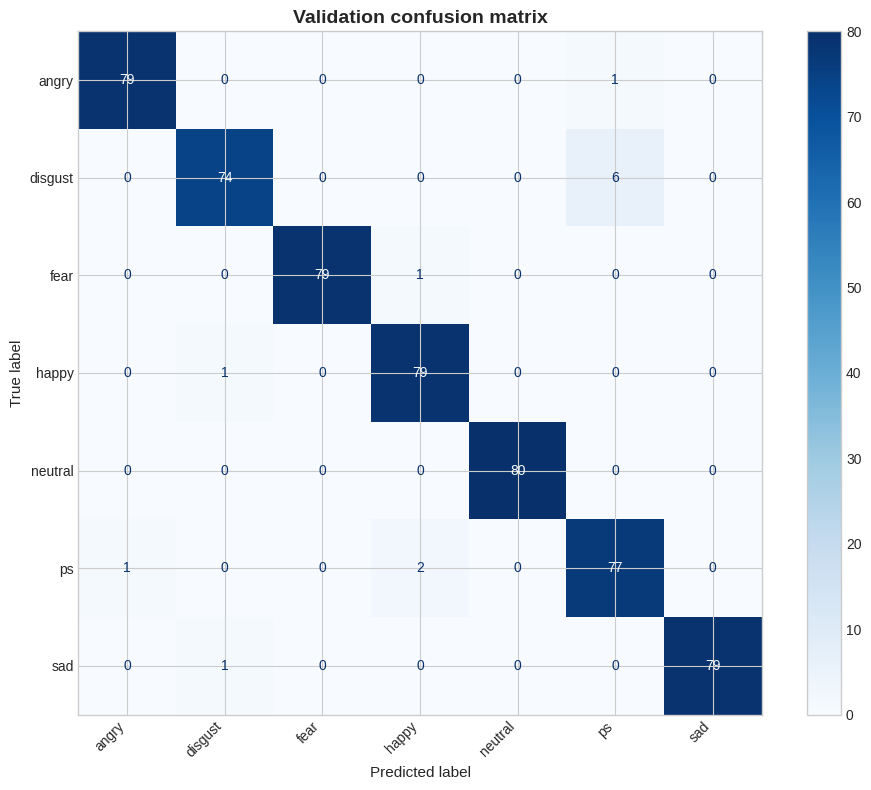

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_val_pred = model.predict(X_val, verbose=0)
y_val_pred_idx = np.argmax(y_val_pred, axis=1)
y_val_idx = np.argmax(y_val, axis=1)
class_names = list(enc.categories_[0])
cm = confusion_matrix(y_val_idx, y_val_pred_idx)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)
ax.set_title('Validation confusion matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Save model and artifacts

Save model (Keras), encoder (pickle), and persist `model_output_dir` path.

In [17]:
import pickle

model_path_keras = os.path.join(MODEL_OUTPUT_DIR, 'anvitha_voice_emotion_model.keras')
model_path_h5 = os.path.join(MODEL_OUTPUT_DIR, 'anvitha_voice_emotion_model.h5')
encoder_path = os.path.join(MODEL_OUTPUT_DIR, 'encoder.pkl')
path_config_path = os.path.join(MODEL_OUTPUT_DIR, 'model_output_dir.txt')

model.save(model_path_keras)
model.save(model_path_h5)
print(f'Saved model (Keras): {model_path_keras}')
print(f'Saved model (H5): {model_path_h5}')

with open(encoder_path, 'wb') as f:
    pickle.dump(enc, f)
print(f'Saved encoder: {encoder_path}')

with open(path_config_path, 'w') as f:
    f.write(MODEL_OUTPUT_DIR)
print(f'Saved model_output_dir path: {path_config_path}')

config = {
    'model_output_dir': MODEL_OUTPUT_DIR,
    'model_path_keras': model_path_keras,
    'model_path_h5': model_path_h5,
    'encoder_path': encoder_path,
    'n_mfcc': 40,
    'duration': 3,
    'offset': 0.5,
    'classes': list(enc.categories_[0])
}
config_path = os.path.join(MODEL_OUTPUT_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved config: {config_path}')


Saved model (Keras): /content/drive/MyDrive/models/anvitha/anvitha_voice_emotion_model.keras
Saved model (H5): /content/drive/MyDrive/models/anvitha/anvitha_voice_emotion_model.h5
Saved encoder: /content/drive/MyDrive/models/anvitha/encoder.pkl
Saved model_output_dir path: /content/drive/MyDrive/models/anvitha/model_output_dir.txt
Saved config: /content/drive/MyDrive/models/anvitha/config.json


## 13. Optional: inference example

Load saved model and encoder and predict on a sample (same MFCC params as training).

In [18]:
# Uncomment and set a path to test inference:
# from tensorflow.keras.models import load_model
# with open(encoder_path, 'rb') as f:
#     enc_loaded = pickle.load(f)
# model_loaded = load_model(model_path_keras)
# feat = extract_mfcc('path/to/audio.wav')
# pred = model_loaded.predict(np.expand_dims(np.expand_dims(feat, 0), -1), verbose=0)
# idx = np.argmax(pred[0])
# emotion = enc_loaded.categories_[0][idx]
# print(f'Predicted: {emotion}')


## Summary

- **Model** and **encoder** are saved under `MODEL_OUTPUT_DIR`.
- `model_output_dir.txt` and `config.json` store the output path and run settings.
- For inference: load model + encoder and use `extract_mfcc()` with same `duration`/`offset`/`n_mfcc` (no scaler).